<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 121 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Fraud Detection &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the fraud model: a tree-ensemble rival, an operating point under a review budget, a resampling shootout, how the cost ratio moves the threshold, and scoring a live transaction, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Fraud Detection: Take It Further
Five extensions of the Chapter 121 fraud model, each with a picture and a plain explanation: try a **tree-ensemble** rival, choose an **operating point under a review budget**, run a **resampling shootout**, watch the **threshold move with the cost ratio**, and **score a live transaction**. We start by rebuilding the cleaned data and models.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import average_precision_score, recall_score, precision_score, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Same clean data, same split</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 121 in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/credit_card_fraud.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'credit_card_fraud.csv')
df = df.drop_duplicates('transaction_id'); df = df[df.amount>0].copy()
df['merchant_category'] = df.merchant_category.astype(str).str.strip().str.lower()
numeric = ['amount','hour','txns_last_hour','foreign_transaction','card_present','account_age_days','distance_from_home_km']
categorical = ['merchant_category']
prep = ColumnTransformer([('num', Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]), numeric), ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)])
X = df[numeric+categorical]; y = df['is_fraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
logit = Pipeline([('prep', prep), ('clf', LogisticRegression(max_iter=3000))]).fit(X_train, y_train)
prob = logit.predict_proba(X_test)[:,1]
print('recap: fraud rate %.1f%%, PR-AUC %.3f' % (y.mean()*100, average_precision_score(y_test, prob)))

recap: fraud rate 3.9%, PR-AUC 0.364


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; A TREE-ENSEMBLE RIVAL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Does a random forest do better?</div>
<div style="color:#4a5578;margin-top:6px">Compare PR-AUC, the metric that matters here.</div>
</div>

logistic PR-AUC   = 0.364
random forest PR-AUC = 0.260


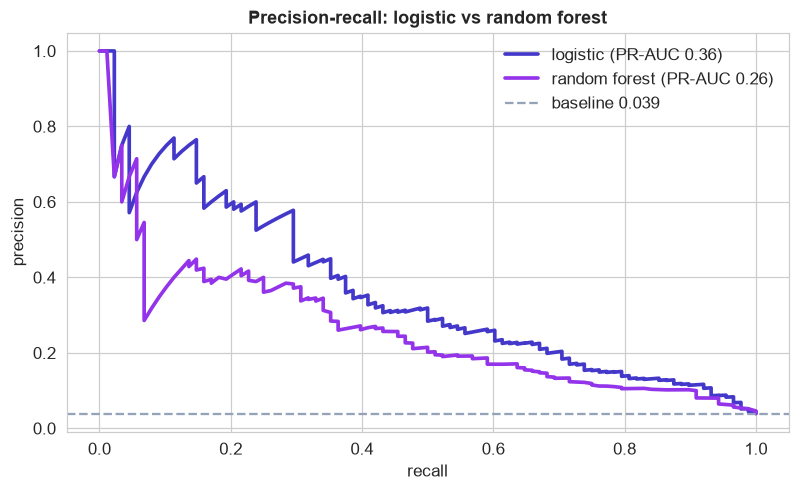

In [4]:
rf = Pipeline([('prep', prep), ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0))]).fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:,1]
print('logistic PR-AUC   = %.3f' % average_precision_score(y_test, prob))
print('random forest PR-AUC = %.3f' % average_precision_score(y_test, rf_prob))
fig, ax = plt.subplots(figsize=(7.4,4.6))
for name,p,c in [('logistic',prob,EM),('random forest',rf_prob,PUR)]:
    pr,rc,_ = precision_recall_curve(y_test, p); ax.plot(rc, pr, color=c, lw=2.4, label=f'{name} (PR-AUC {average_precision_score(y_test,p):.2f})')
ax.axhline(y_test.mean(), color=GREY, ls='--', label=f'baseline {y_test.mean():.3f}')
ax.set(xlabel='recall', ylabel='precision', title='Precision-recall: logistic vs random forest'); ax.legend()
plt.tight_layout(); plt.show()

**Flexible is not automatically better.** Fraud rules are often full of 'foreign AND card-not-present AND large' combinations that trees model natively, so a forest is always worth trying. But on this data, whose risk factors are mostly additive, the **logistic model actually holds its PR-AUC lead**, echoing Chapter 120's lesson: complexity must earn its place. In real fraud systems with richer interactions, gradient-boosted trees (XGBoost/LightGBM) usually do win, which is why they are the industry workhorse, the discipline is to compare on **PR-AUC**, not on a hunch.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; AN OPERATING POINT UNDER BUDGET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The review team can only handle so many alerts</div>
<div style="color:#4a5578;margin-top:6px">Turn a capacity limit into a recall number.</div>
</div>

if the team reviews the top-K riskiest transactions per test batch:
  review  50 alerts -> catch 26/88 frauds (recall 0.30), precision 0.52
  review 100 alerts -> catch 35/88 frauds (recall 0.40), precision 0.35
  review 150 alerts -> catch 44/88 frauds (recall 0.50), precision 0.29
  review 200 alerts -> catch 52/88 frauds (recall 0.59), precision 0.26
  review 300 alerts -> catch 60/88 frauds (recall 0.68), precision 0.20


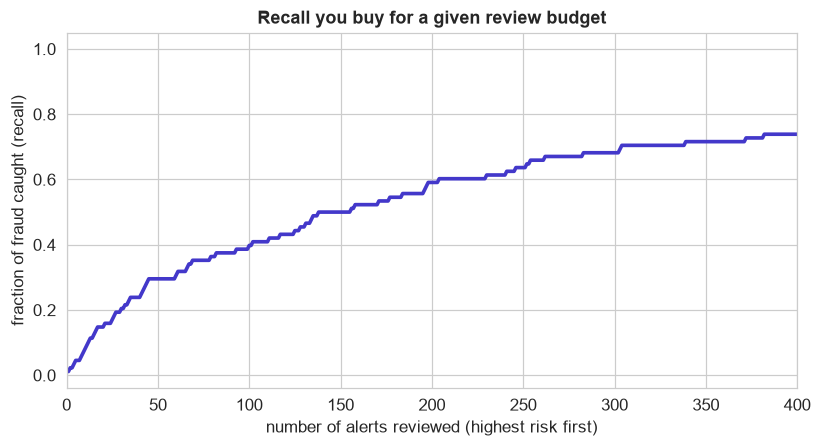

In [5]:
order = np.argsort(-prob)                              # rank transactions by fraud probability
y_sorted = y_test.values[order]
budgets = [50, 100, 150, 200, 300]
print('if the team reviews the top-K riskiest transactions per test batch:')
for k in budgets:
    caught = y_sorted[:k].sum(); rec = caught / y_test.sum()
    print(f'  review {k:3d} alerts -> catch {caught:2d}/{y_test.sum()} frauds (recall {rec:.2f}), precision {caught/k:.2f}')
cum_recall = np.cumsum(y_sorted) / y_test.sum()
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.plot(np.arange(1,len(y_sorted)+1), cum_recall, color=EM, lw=2.4)
ax.set(xlim=(0,400), xlabel='number of alerts reviewed (highest risk first)', ylabel='fraction of fraud caught (recall)', title='Recall you buy for a given review budget')
plt.tight_layout(); plt.show()

**Capacity is the real constraint.** A team cannot chase every alert. Ranking transactions by fraud probability and reviewing the **top K** converts a staffing budget directly into recall: reviewing just the few hundred riskiest transactions catches most of the fraud, and the curve's bend shows where extra reviewers stop paying off. This is often how a threshold is set in practice, not from a cost formula but from how many alerts humans can work per day.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; RESAMPLING SHOOTOUT</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">class weights vs SMOTE vs undersampling</div>
<div style="color:#4a5578;margin-top:6px">Which rebalancing wins on PR-AUC?</div>
</div>

plain          PR-AUC 0.364
class_weight   PR-AUC 0.355
SMOTE          PR-AUC 0.358
undersample    PR-AUC 0.330


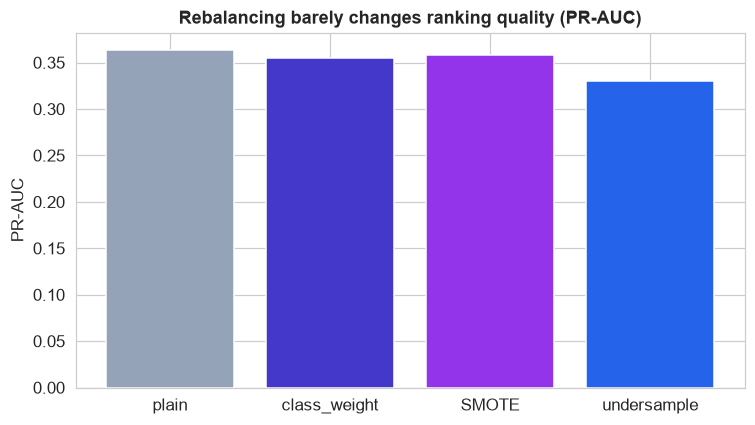

In [6]:
strategies = {
  'plain': Pipeline([('prep',prep),('clf',LogisticRegression(max_iter=3000))]),
  'class_weight': Pipeline([('prep',prep),('clf',LogisticRegression(max_iter=3000,class_weight='balanced'))]),
  'SMOTE': ImbPipeline([('prep',prep),('smote',SMOTE(random_state=0)),('clf',LogisticRegression(max_iter=3000))]),
  'undersample': ImbPipeline([('prep',prep),('under',RandomUnderSampler(random_state=0)),('clf',LogisticRegression(max_iter=3000))])}
praucs = {}
for name, model in strategies.items():
    model.fit(X_train, y_train); praucs[name] = average_precision_score(y_test, model.predict_proba(X_test)[:,1])
    print(f'{name:14s} PR-AUC {praucs[name]:.3f}')
fig, ax = plt.subplots(figsize=(7,4)); ax.bar(praucs.keys(), praucs.values(), color=[GREY,EM,PUR,BLUE])
ax.set(ylabel='PR-AUC', title='Rebalancing barely changes ranking quality (PR-AUC)'); plt.tight_layout(); plt.show()

**A subtle but important truth.** Class weights, SMOTE, and undersampling all dramatically change the default-threshold recall, but they barely change **PR-AUC**, the threshold-free ranking quality. That is because rebalancing mostly *shifts the decision boundary*, which is the same thing as moving the threshold. The practical takeaway: pick whichever is convenient (class weights are simplest), then spend your effort on the **threshold / operating point**, which is what actually changes outcomes.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; THE COST RATIO MOVES THE LINE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">How much is a false alarm worth?</div>
<div style="color:#4a5578;margin-top:6px">Sweep the cost and watch the optimal threshold shift.</div>
</div>

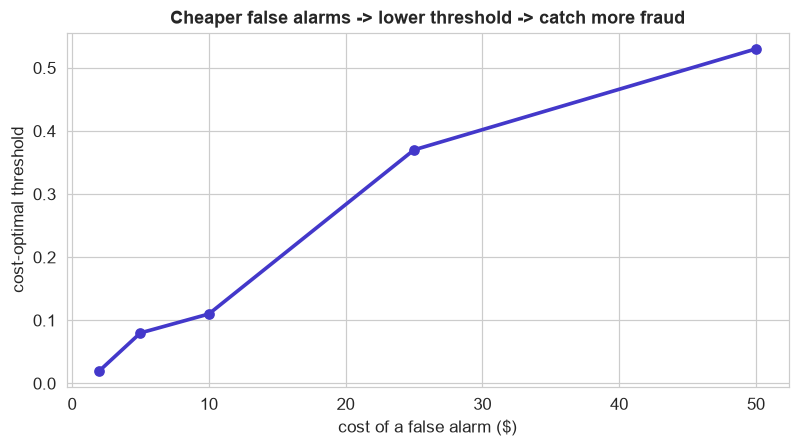

as a false alarm gets cheaper, the optimal threshold drops and recall rises


In [7]:
amt = X_test['amount'].values; yv = y_test.values; ths = np.linspace(0.02,0.6,59)
fa_costs = [2, 5, 10, 25, 50]
opt = []
for fa in fa_costs:
    cost = [amt[(prob<t)&(yv==1)].sum() + ((prob>=t)&(yv==0)).sum()*fa for t in ths]
    opt.append(ths[int(np.argmin(cost))])
fig, ax = plt.subplots(figsize=(7.4,4.2))
ax.plot(fa_costs, opt, 'o-', color=EM, lw=2.4); ax.set(xlabel='cost of a false alarm ($)', ylabel='cost-optimal threshold', title='Cheaper false alarms -> lower threshold -> catch more fraud')
plt.tight_layout(); plt.show()
print('as a false alarm gets cheaper, the optimal threshold drops and recall rises')

**The threshold is a business decision, made explicit.** When a false alarm is cheap (a quick text to the cardholder), the optimal threshold drops toward zero, flag aggressively. When each alert is expensive (a manual investigation), the threshold rises to protect analyst time. There is no universally correct cutoff; it follows directly from the ratio of the two error costs, which is a business input, not a statistical one.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; SCORE A LIVE TRANSACTION</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The model in action</div>
<div style="color:#4a5578;margin-top:6px">One transaction in, a risk score out.</div>
</div>

In [8]:
risky = pd.DataFrame([{'amount':1450,'hour':3,'txns_last_hour':6,'foreign_transaction':1,'card_present':0,
    'account_age_days':40,'distance_from_home_km':900,'merchant_category':'electronics'}])
safe = pd.DataFrame([{'amount':38,'hour':13,'txns_last_hour':1,'foreign_transaction':0,'card_present':1,
    'account_age_days':1500,'distance_from_home_km':6,'merchant_category':'grocery'}])
cw = Pipeline([('prep',prep),('clf',LogisticRegression(max_iter=3000,class_weight='balanced'))]).fit(X_train,y_train)
print('suspicious transaction -> fraud probability %.0f%%' % (cw.predict_proba(risky)[0,1]*100))
print('ordinary transaction   -> fraud probability %.0f%%' % (cw.predict_proba(safe)[0,1]*100))

suspicious transaction -> fraud probability 100%
ordinary transaction   -> fraud probability 2%


**This is what runs at swipe time.** A large, late-night, foreign, card-not-present electronics purchase on a 40-day-old account, far from home, lights up as high risk; a small daytime grocery run on an established local account barely registers. Compare the score to the cost-tuned threshold and the system decides in milliseconds whether to approve, challenge, or hold the transaction.

## Take-it-further summary, in plain terms

- **A tree ensemble** can edge the linear model by catching feature combinations, at the cost of interpretability.
- **A review budget** converts directly into recall by working the highest-risk alerts first.
- **Rebalancing barely moves PR-AUC**, it mostly shifts the threshold, so tune the threshold directly.
- **The optimal threshold follows the cost ratio**: cheaper false alarms mean a lower cutoff and more fraud caught.
- **Scoring a transaction is one call**, the deployed pipeline turns a raw record into an approve/hold decision.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>